# 03 Image Scraping

## Goal
This notebook builds an image dataset from the literary text processed in the previous notebook.

The notebook will:
- load the processed literary units
- construct image search queries from city groups and keywords
- create image folders for each text unit
- download reference images
- save image metadata for later analysis and generation

In [4]:
#!pip install duckduckgo-search requests pillow

## Step 1 — Import libraries

Import the libraries needed for:
- loading processed text units
- loading the Flickr image dataset
- scoring and matching
- image preview

In [18]:
from pathlib import Path
import json
import ast
import re
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Step 2 — Load project config

Load shared project paths from the JSON config file.

In [19]:
PROJECT_ROOT = Path.cwd().resolve().parent
CONFIG_PATH = PROJECT_ROOT / "src" / "project_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

OUTPUT_TABLES_DIR = Path(config["output_tables_dir"])
RAW_IMAGES_DIR = Path(config["raw_images_dir"])

print("Output tables dir:", OUTPUT_TABLES_DIR)
print("Raw images dir:", RAW_IMAGES_DIR)

Output tables dir: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\tables
Raw images dir: D:\Work\Workspace\Projects\Python\data-driven-surface\data\raw\scraped_images


## Step 3 — Load the processed literary units

Load the structured literary units generated in the previous notebook.

In [21]:
processed_csv_path = PROJECT_ROOT / "data" / "processed" / "literary_text" / "invisible_cities_units_processed.csv"
if not processed_csv_path.exists():
    raise FileNotFoundError(
        f"Processed literary CSV not found: {processed_csv_path}\n"
        "Please run 02_literary_text_processing.ipynb first."
    )

unit_df = pd.read_csv(processed_csv_path)

if "keywords" in unit_df.columns:
    unit_df["keywords"] = unit_df["keywords"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else x
    )

unit_df.head()

,unit_id,city_group,text,clean_text,char_count,word_count,keywords,dominant_emotion,joy,sadness,fear,awe,desire
0,1,Cities & Memory 1,Leaving there and proceeding for three days to...,Leaving there and proceeding for three days to...,745,136,"[evening, leaving, proceeding, east, reach, di...",joy,2,0,0,1,1
1,2,Cities & Memory 2,When a man rides a long time through wild regi...,When a man rides a long time through wild regi...,742,131,"[isidora, spiral, young, rides, wild, regions,...",desire,0,0,0,0,1
2,3,Cities & Desire 1,There are two ways of describing the city of D...,There are two ways of describing the city of D...,1288,221,"[dorothea, quarters, morning, desert, caravan,...",desire,0,0,0,0,1
3,4,Cities & Memory 3,"In vain, great-hearted Kublai, shall I attempt...","In vain, great-hearted Kublai, shall I attempt...",1684,306,"[past, zaira, tell, steps, streets, telling, h...",neutral,0,0,0,0,0
4,5,Cities & Desire 2,"At the end of three days, moving southward, yo...","At the end of three days, moving southward, yo...",1368,248,"[anastasia, desire, sometimes, agate, onyx, ch...",desire,1,0,0,0,4


## Step 4 — Load the Flickr dataset

Load the curated Flickr-based urban image dataset created in notebook 00.

In [22]:
flickr_csv_path = OUTPUT_TABLES_DIR / "flickr_dataset.csv"

if not flickr_csv_path.exists():
    raise FileNotFoundError(
        f"Flickr dataset CSV not found: {flickr_csv_path}\n"
        "Please run 00_flickr_dataset_builder.ipynb first."
    )

image_df = pd.read_csv(flickr_csv_path)
image_df.head()

,city_type,query,page,image_url,title,tags,local_path
0,desert_city,desert city architecture sand city,1,https://live.staticflickr.com/8472/8105498538_...,desert.city,road street urban signs skyscraper sand citysc...,D:\Work\Workspace\Projects\Python\data-driven-...
1,desert_city,desert city architecture sand city,1,https://live.staticflickr.com/6158/6186017968_...,Where the streets have no name..,old city travel panorama india house building ...,D:\Work\Workspace\Projects\Python\data-driven-...
2,desert_city,desert city architecture sand city,1,https://live.staticflickr.com/8524/8632033539_...,Dubai Marina,blue sky urban panorama water skyline architec...,D:\Work\Workspace\Projects\Python\data-driven-...
3,desert_city,desert city architecture sand city,1,https://live.staticflickr.com/7429/10749910896...,NaN,light urban architecture canon eos licht sand ...,D:\Work\Workspace\Projects\Python\data-driven-...
4,desert_city,desert city architecture sand city,1,https://live.staticflickr.com/5146/5691799788_...,A City By Day Just Isn’t the Same,seattle county city tower beautiful weather sk...,D:\Work\Workspace\Projects\Python\data-driven-...


## Step 5 — Prepare image metadata for retrieval

Create a unified searchable text field from image metadata.

In [23]:
image_df["title"] = image_df["title"].fillna("")
image_df["tags"] = image_df["tags"].fillna("")
image_df["query"] = image_df["query"].fillna("")

image_df["search_text"] = (
    image_df["city_type"].fillna("").str.lower() + " " +
    image_df["title"].str.lower() + " " +
    image_df["tags"].str.lower() + " " +
    image_df["query"].str.lower()
)

image_df[["city_type", "title", "query", "search_text"]].head()

,city_type,title,query,search_text
0,desert_city,desert.city,desert city architecture sand city,desert_city desert.city road street urban sign...
1,desert_city,Where the streets have no name..,desert city architecture sand city,desert_city where the streets have no name.. o...
2,desert_city,Dubai Marina,desert city architecture sand city,desert_city dubai marina blue sky urban panora...
3,desert_city,,desert city architecture sand city,desert_city light urban architecture canon eo...
4,desert_city,A City By Day Just Isn’t the Same,desert city architecture sand city,desert_city a city by day just isn’t the same ...


## Step 6 — Define city-type hint rules

Use lightweight rules to map literary content into broad spatial image categories.
This helps guide retrieval beyond keyword overlap alone.

In [24]:
city_type_hint_rules = {
    "desert_city": ["desert", "sand", "caravan", "dunes", "arid"],
    "circular_city": ["circular", "radial", "ring", "round", "concentric"],
    "vertical_city": ["tower", "towers", "vertical", "skyscraper", "high-rise"],
    "dense_city": ["dense", "crowded", "compact", "cluster", "packed"],
    "layered_city": ["layered", "stacked", "multi-level", "terraced", "overlapping"],
    "floating_city": ["floating", "sky", "airborne", "elevated", "hovering"],
    "ruin_city": ["ruin", "ruins", "abandoned", "broken", "decay"],
    "monumental_city": ["monumental", "grand", "palace", "cathedral", "massive"],
    "surreal_city": ["surreal", "dream", "impossible", "fantasy", "strange"]
}

## Step 7 — Define retrieval scoring

Score each image against a literary unit using:
- keyword overlap
- emotion overlap
- city-type hints

In [33]:
emotion_hint_words = {
    "joy": ["bright", "celebratory", "light", "gold", "sunny", "vivid"],
    "sadness": ["dark", "ruin", "empty", "abandoned", "lonely", "decay"],
    "fear": ["shadow", "ominous", "void", "night", "narrow", "threat"],
    "desire": ["dream", "fantasy", "mystical", "ornate", "seductive", "surreal"],
    "awe": ["grand", "vast", "monumental", "epic", "towering", "ornate"],
    "neutral": []
}

def infer_city_type_hints(keywords):
    if not isinstance(keywords, list):
        return []

    keywords_lower = [k.lower() for k in keywords]
    matched_types = []

    for city_type, hint_words in city_type_hint_rules.items():
        if any(word in keywords_lower for word in hint_words):
            matched_types.append(city_type)

    return matched_types

def score_image_for_unit(unit_row, image_row):
    score = 0

    unit_keywords = unit_row["keywords"] if isinstance(unit_row["keywords"], list) else []
    unit_keywords = [k.lower() for k in unit_keywords]
    emotion = str(unit_row["dominant_emotion"]).lower()

    title = str(image_row["title"]).lower()
    tags = str(image_row["tags"]).lower()
    query = str(image_row["query"]).lower()
    image_text = f"{title} {tags} {query}"

    # 0. hard filtering: remove illustration / CG / AI / cartoon-like content
    banned_words = [
        "illustration", "drawing", "painting", "concept art",
        "digital art", "artwork", "anime", "cartoon", "render", "cgi"
    ]
    if any(word in image_text for word in banned_words):
        return -999

    # 1. keyword overlap
    keyword_hits = sum(1 for kw in unit_keywords if kw in image_text)
    score += keyword_hits * 3

    # 2. emotion hint overlap
    emotion_words = emotion_hint_words.get(emotion, [])
    emotion_hits = sum(1 for w in emotion_words if w in image_text)
    score += emotion_hits * 2

    # 3. city-type hint match
    hinted_city_types = infer_city_type_hints(unit_keywords)
    if image_row["city_type"] in hinted_city_types:
        score += 6

    # 4. small penalty for over-dominant generic class
    if image_row["city_type"] == "surreal_city":
        score -= 2

    return score

## Step 8 — Retrieve top matching images for each literary unit

For each literary unit, retrieve the top three matching Flickr images.

In [34]:
retrieval_records = []

for unit_row in unit_df.itertuples(index=False):
    unit_dict = {
        "unit_id": unit_row.unit_id,
        "city_group": unit_row.city_group,
        "keywords": unit_row.keywords,
        "dominant_emotion": unit_row.dominant_emotion
    }

    scored_rows = []

    for image_row in image_df.itertuples(index=False):
        image_dict = {
            "city_type": image_row.city_type,
            "title": image_row.title,
            "tags": image_row.tags,
            "query": image_row.query,
            "search_text": image_row.search_text,
            "image_url": image_row.image_url,
            "local_path": image_row.local_path
        }

        score = score_image_for_unit(unit_dict, image_dict)

        # skip filtered-out images
        if score < 0:
            continue

        scored_rows.append({
            "unit_id": unit_row.unit_id,
            "city_group": unit_row.city_group,
            "dominant_emotion": unit_row.dominant_emotion,
            "keywords": unit_row.keywords,
            "matched_city_type": image_row.city_type,
            "image_url": image_row.image_url,
            "local_path": image_row.local_path,
            "title": image_row.title,
            "tags": image_row.tags,
            "query": image_row.query,
            "score": score
        })

    scored_df = pd.DataFrame(scored_rows)
    scored_df = scored_df.sort_values(by="score", ascending=False)

    # keep category diversity in top 3
    selected = []
    used_types = set()

    for _, row in scored_df.iterrows():
        if row["matched_city_type"] not in used_types:
            selected.append(row)
            used_types.add(row["matched_city_type"])
        if len(selected) == 3:
            break

    scored_df = pd.DataFrame(selected)
    scored_df["image_rank"] = range(1, len(scored_df) + 1)

    retrieval_records.extend(scored_df.to_dict(orient="records"))

## Step 9 — Create the retrieval metadata table

Combine all top matches into a structured dataframe.

In [35]:
metadata_df = pd.DataFrame(retrieval_records)

metadata_df = metadata_df[
    [
        "unit_id",
        "city_group",
        "dominant_emotion",
        "keywords",
        "matched_city_type",
        "image_rank",
        "title",
        "image_url",
        "local_path",
        "score"
    ]
].copy()

metadata_df.head(10)

,unit_id,city_group,dominant_emotion,keywords,matched_city_type,image_rank,title,image_url,local_path,score
0,1,Cities & Memory 1,joy,"[evening, leaving, proceeding, east, reach, di...",vertical_city,1,Lights of Awareness,https://live.staticflickr.com/3950/14914314754...,D:\Work\Workspace\Projects\Python\data-driven-...,8
1,1,Cities & Memory 1,joy,"[evening, leaving, proceeding, east, reach, di...",circular_city,2,Golden Statues & Eiffel Tower Viewed From The ...,https://live.staticflickr.com/65535/5223700921...,D:\Work\Workspace\Projects\Python\data-driven-...,7
2,1,Cities & Memory 1,joy,"[evening, leaving, proceeding, east, reach, di...",ruin_city,3,Dystopian,https://live.staticflickr.com/3953/15477020460...,D:\Work\Workspace\Projects\Python\data-driven-...,5
3,2,Cities & Memory 2,desire,"[isidora, spiral, young, rides, wild, regions,...",surreal_city,1,The Stars Are Out Tonight,https://live.staticflickr.com/65535/5457732673...,D:\Work\Workspace\Projects\Python\data-driven-...,7
4,2,Cities & Memory 2,desire,"[isidora, spiral, young, rides, wild, regions,...",floating_city,2,Fantasy in Dream 2011,https://live.staticflickr.com/8845/18449968065...,D:\Work\Workspace\Projects\Python\data-driven-...,4
5,2,Cities & Memory 2,desire,"[isidora, spiral, young, rides, wild, regions,...",desert_city,3,A City By Day Just Isn’t the Same,https://live.staticflickr.com/5146/5691799788_...,D:\Work\Workspace\Projects\Python\data-driven-...,3
6,3,Cities & Desire 1,desire,"[dorothea, quarters, morning, desert, caravan,...",desert_city,1,Coastal Dubai,https://live.staticflickr.com/4051/4708242980_...,D:\Work\Workspace\Projects\Python\data-driven-...,15
7,3,Cities & Desire 1,desire,"[dorothea, quarters, morning, desert, caravan,...",vertical_city,2,Dystopian Shard,https://live.staticflickr.com/705/31620092615_...,D:\Work\Workspace\Projects\Python\data-driven-...,12
8,3,Cities & Desire 1,desire,"[dorothea, quarters, morning, desert, caravan,...",surreal_city,3,The dreamlike place,https://live.staticflickr.com/65535/5413211390...,D:\Work\Workspace\Projects\Python\data-driven-...,8
9,4,Cities & Memory 3,neutral,"[past, zaira, tell, steps, streets, telling, h...",layered_city,1,2017 - Montreal - Row Housing Stairs,https://live.staticflickr.com/4359/37351165081...,D:\Work\Workspace\Projects\Python\data-driven-...,9


## Step 10 — Preview sample retrieval results

Inspect the top retrieved images for a few literary units.

In [36]:
metadata_df.groupby("unit_id").head(3).head(15)

,unit_id,city_group,dominant_emotion,keywords,matched_city_type,image_rank,title,image_url,local_path,score
0,1,Cities & Memory 1,joy,"[evening, leaving, proceeding, east, reach, di...",vertical_city,1,Lights of Awareness,https://live.staticflickr.com/3950/14914314754...,D:\Work\Workspace\Projects\Python\data-driven-...,8
1,1,Cities & Memory 1,joy,"[evening, leaving, proceeding, east, reach, di...",circular_city,2,Golden Statues & Eiffel Tower Viewed From The ...,https://live.staticflickr.com/65535/5223700921...,D:\Work\Workspace\Projects\Python\data-driven-...,7
2,1,Cities & Memory 1,joy,"[evening, leaving, proceeding, east, reach, di...",ruin_city,3,Dystopian,https://live.staticflickr.com/3953/15477020460...,D:\Work\Workspace\Projects\Python\data-driven-...,5
3,2,Cities & Memory 2,desire,"[isidora, spiral, young, rides, wild, regions,...",surreal_city,1,The Stars Are Out Tonight,https://live.staticflickr.com/65535/5457732673...,D:\Work\Workspace\Projects\Python\data-driven-...,7
4,2,Cities & Memory 2,desire,"[isidora, spiral, young, rides, wild, regions,...",floating_city,2,Fantasy in Dream 2011,https://live.staticflickr.com/8845/18449968065...,D:\Work\Workspace\Projects\Python\data-driven-...,4
5,2,Cities & Memory 2,desire,"[isidora, spiral, young, rides, wild, regions,...",desert_city,3,A City By Day Just Isn’t the Same,https://live.staticflickr.com/5146/5691799788_...,D:\Work\Workspace\Projects\Python\data-driven-...,3
6,3,Cities & Desire 1,desire,"[dorothea, quarters, morning, desert, caravan,...",desert_city,1,Coastal Dubai,https://live.staticflickr.com/4051/4708242980_...,D:\Work\Workspace\Projects\Python\data-driven-...,15
7,3,Cities & Desire 1,desire,"[dorothea, quarters, morning, desert, caravan,...",vertical_city,2,Dystopian Shard,https://live.staticflickr.com/705/31620092615_...,D:\Work\Workspace\Projects\Python\data-driven-...,12
8,3,Cities & Desire 1,desire,"[dorothea, quarters, morning, desert, caravan,...",surreal_city,3,The dreamlike place,https://live.staticflickr.com/65535/5413211390...,D:\Work\Workspace\Projects\Python\data-driven-...,8
9,4,Cities & Memory 3,neutral,"[past, zaira, tell, steps, streets, telling, h...",layered_city,1,2017 - Montreal - Row Housing Stairs,https://live.staticflickr.com/4359/37351165081...,D:\Work\Workspace\Projects\Python\data-driven-...,9


## Step 11 — Show sample matched images

Display the matched images for a few selected literary units.

In [37]:
def show_unit_images(unit_id, max_images=3):
    subset = metadata_df[metadata_df["unit_id"] == unit_id].sort_values("image_rank").head(max_images)

    if subset.empty:
        print(f"No images found for unit {unit_id}")
        return

    plt.figure(figsize=(12, 4))

    for i, row in enumerate(subset.itertuples(index=False)):
        img = Image.open(row.local_path)

        plt.subplot(1, max_images, i + 1)
        plt.imshow(img)
        plt.title(
            f"Unit {row.unit_id}\n{row.city_group}\nRank {row.image_rank}\n{row.matched_city_type}",
            fontsize=10
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

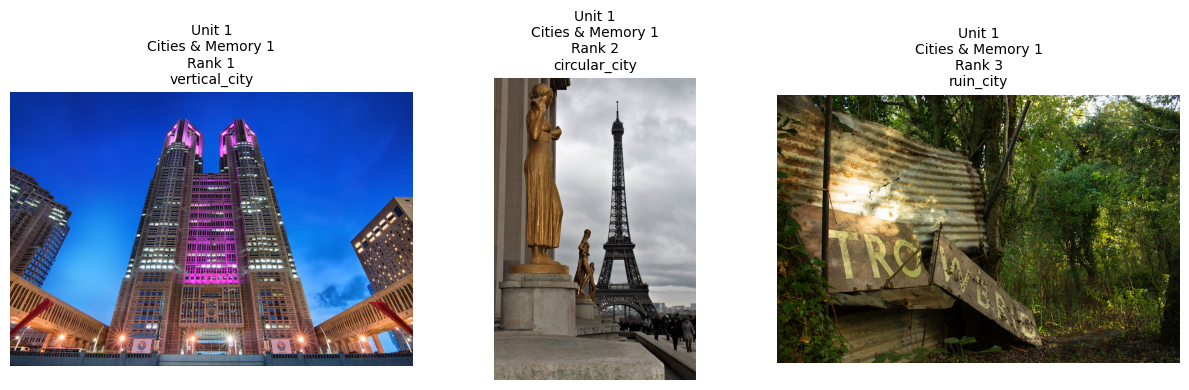

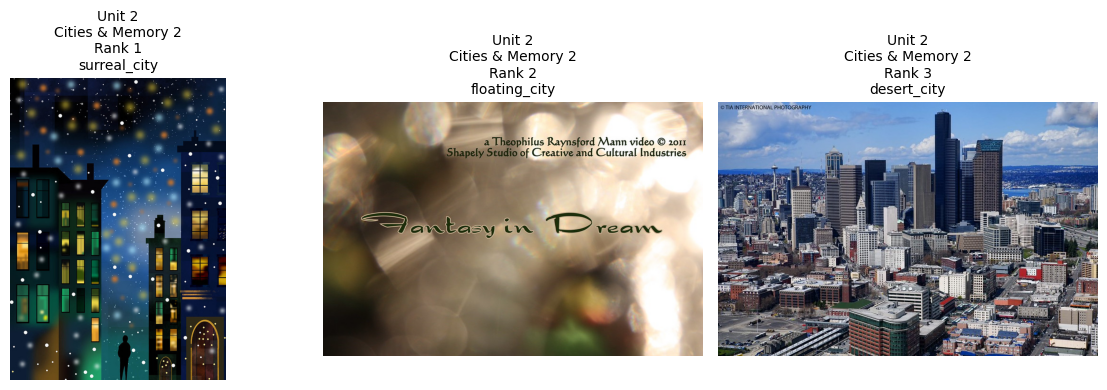

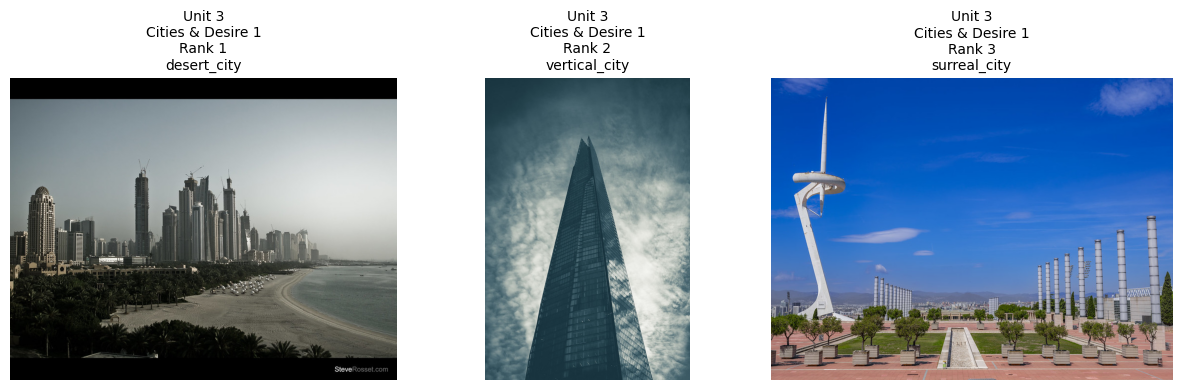

In [38]:
show_unit_images(1, max_images=3)
show_unit_images(2, max_images=3)
show_unit_images(3, max_images=3)

## Step 12 — Save retrieval metadata

Save the retrieval table for later inspection and downstream notebooks.

In [39]:
metadata_csv_path = OUTPUT_TABLES_DIR / "image_scraping_metadata.csv"

metadata_df.to_csv(metadata_csv_path, index=False, encoding="utf-8-sig")

print("Saved metadata to:", metadata_csv_path)

Saved metadata to: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\tables\image_scraping_metadata.csv


## Step 13 — Summarise retrieval results

Check how many image matches were assigned across all literary units.

In [40]:
print("Total matched records:", len(metadata_df))
print("Total literary units covered:", metadata_df["unit_id"].nunique())
print("\nMatched city-type distribution:")
print(metadata_df["matched_city_type"].value_counts())

Total matched records: 135
Total literary units covered: 45

Matched city-type distribution:
matched_city_type
vertical_city      28
ruin_city          27
desert_city        24
surreal_city       17
circular_city      15
floating_city      11
monumental_city     8
layered_city        5
Name: count, dtype: int64
